In [1]:
import pandas as pd 
from pathlib import Path
import re 
import json 
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import numpy as np

In [2]:
d = Path("/home/finn/workspace/creatures/logs/")
assert d.exists()

In [3]:
d = sorted(list(d.glob("*.log")))
p = d[-1]

In [4]:
with open(p) as f:
    n_lines = sum(1 for _ in f)
print(n_lines)

8119


In [5]:
_header_pat = re.compile(
    r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
    r"\[unix_ts=(?P<unix_timestamp>\d+)\] "
    r"\[frame=(?P<frame>\d+)\] "
    r"\[level=INFO\] "
    r"animal_despawn "
    r"reason=(?P<reason>\w+) "
    r"lifetime_frames=(?P<lifetime>\d+) "
    r"animal=Animal\s*\{(?P<animal>.+)\}$"
)

def _split_top_level(text):
    """Split on commas not inside any bracket/brace/paren."""
    depth, parts, current = 0, [], []
    for ch in text:
        if ch in "({[":
            depth += 1
        elif ch in ")}]":
            depth -= 1
        elif ch == "," and depth == 0:
            parts.append("".join(current).strip())
            current = []
            continue
        current.append(ch)
    if current:
        parts.append("".join(current).strip())
    return parts

def _coerce(val):
    if val == "None":
        return None
    m = re.match(r"^Some\((.+)\)$", val)
    if m:
        return _coerce(m.group(1))
    try:
        return int(val)
    except ValueError:
        pass
    try:
        return float(val)
    except ValueError:
        pass
    return val

def extract_animal_data(line):
    m = _header_pat.match(line.rstrip())
    if m is None:
        return None

    animal = {}
    for part in _split_top_level(m.group("animal")):
        key, sep, val = part.partition(":")
        if sep:
            animal[key.strip()] = _coerce(val.strip())

    return {
        "simulation_start_ts": int(m.group("simulation_start_ts")),
        "unix_timestamp": float(m.group("unix_timestamp")),
        "lifetime": float(m.group("lifetime")),
        "reason": m.group("reason"),
        **animal,
    }


In [6]:
with open(p) as f:
    df = pd.DataFrame([r for line in f if (r := extract_animal_data(line)) is not None])

In [7]:
df

,simulation_start_ts,unix_timestamp,lifetime,reason,id,parent_id,diet,position,velocity,energy,initial_energy,size,color,vision,genome,spawn_at,despawn_at,family,generation
0,1782892350,1.782892e+09,29.0,collision,10557370568494604688,NaN,Carnivore,"Vec2(-2.7337334, 90.08407)","Vec2(-8.809942, 83.52718)",0.0,50.0,10.0,"Srgba(Srgba { red: 1.0, green: 0.0, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",0,29,1,0
1,1782892350,1.782892e+09,92.0,starvation,12880798627741518039,NaN,Herbivore,"Vec2(-135.55814, 480.00174)","Vec2(0.6775289, 396.35114)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.0, green: 0.8, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [4.8738174, 1.9907117, 3.28818...",557,649,627287118,0
2,1782892350,1.782892e+09,635.0,starvation,10891699968442042436,NaN,Omnivore,"Vec2(211.56271, 349.99536)","Vec2(292.7398, -0.7859081)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.5, green: 0.5, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [2.3791757, 1.878279, -2.69001...",359,994,3495486395,16
3,1782892350,1.782892e+09,106.0,starvation,8954854154554024487,NaN,Carnivore,"Vec2(508.48965, 418.15964)","Vec2(49.432747, -356.87613)",0.0,50.0,10.0,"Srgba(Srgba { red: 1.0, green: 0.0, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [2.3822393, 0.8808193, -4.0521...",1117,1223,1347107894,0
4,1782892350,1.782892e+09,2369.0,starvation,14458551477610640011,NaN,Herbivore,"Vec2(298.8862, 76.30695)","Vec2(1.0909934e-8, -1.3126031e-9)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.0, green: 0.8, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [4.0, 0.0, 0.0, 4.0, 0.0, 0.0,...",0,2369,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1473,1782892350,1.782893e+09,1212.0,starvation,12856612441235471561,2.400328e+17,Herbivore,"Vec2(-361.5912, -216.29683)","Vec2(-184.78218, -78.282684)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.0, green: 0.8, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [4.4184365, 0.7753799, -0.0204...",12700,13912,0,31
1474,1782892350,1.782893e+09,283.0,collision,8372238483565753174,2.058106e+17,Herbivore,"Vec2(575.3902, -481.68143)","Vec2(44.044525, 47.36974)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.0, green: 0.8, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [3.8040342, 0.96822643, -1.478...",13633,13916,0,35
1475,1782892350,1.782893e+09,1132.0,starvation,7504009978629430007,1.285661e+19,Herbivore,"Vec2(316.04837, -491.78656)","Vec2(-88.66393, -140.87552)",0.0,50.0,10.0,"Srgba(Srgba { red: 0.0, green: 0.8, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [4.7671123, 0.31687605, 0.1009...",12786,13918,0,32
1476,1782892350,1.782893e+09,7.0,collision,10415583361875624326,8.480998e+17,Carnivore,"Vec2(575.4456, -480.65488)","Vec2(-2.2758899, 0.0074244402)",0.0,50.0,10.0,"Srgba(Srgba { red: 1.0, green: 0.0, blue: 0.0,...",Vision { range: 80.0 },"Genome { genes: [-0.2605849, 0.2715584, 0.9309...",13913,13920,1,4


In [8]:
_genome_pat = re.compile(r"Genome \{ genes: \[(.+?)\] \}")

def parse_genome(s):
    m = _genome_pat.search(s)
    return np.fromstring(m.group(1), sep=", ") if m else None

df["genome"] =df["genome"].map(parse_genome)

In [9]:
df["family"]

0                1
1        627287118
2       3495486395
3       1347107894
4                0
           ...    
1473             0
1474             0
1475             0
1476             1
1477             0
Name: family, Length: 1478, dtype: int64

In [10]:
from sklearn.decomposition import PCA
X = np.stack(df["genome"].to_list())
pca = PCA(n_components=2)
X_transformed  = pca.fit_transform(X)

In [11]:
unique_families = np.sort(df["family"].dropna().unique())
palette = sns.color_palette("husl", n_colors=len(unique_families))

family_to_color = {fam: palette[i] for i, fam in enumerate(unique_families)}
family_colors = df["family"].map(family_to_color)

In [12]:
family_colors.iloc[0]

(0.9693365714938805, 0.45256341425555374, 0.42212204800096126)

In [13]:
import plotly.express as px

color_discrete_map = {
    str(fam): f"rgb({int(r*255)},{int(g*255)},{int(b*255)})"
    for fam, (r, g, b) in family_to_color.items()
}

fig = px.scatter(
    x=X_transformed[:, 0],
    y=X_transformed[:, 1],
    color=df["family"].astype(str),
    color_discrete_map=color_discrete_map,
    labels={"x": "PC1", "y": "PC2", "color": "Family"},
)
fig.update_layout(xaxis_range=[-30, -10], yaxis_range=[-10, 10])
fig.show()

<Axes: xlabel='diet', ylabel='lifetime'>

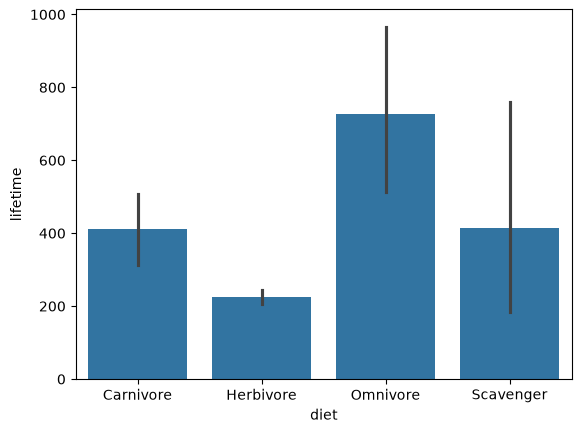

In [14]:
sns.barplot(data=df, x="diet", y="lifetime")

ValueError: Invalid RGBA argument: 'diet'

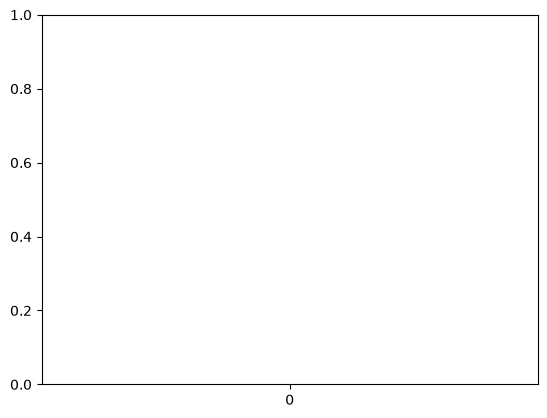

In [15]:
df_fam = df.sort_values(by = "lifetime",axis = 0, ascending=False)[:1000]
sns.barplot(data=df_fam, x="family", y="lifetime", color="diet")

# Population

In [ ]:
def extract_population_data(line):
    m = re.match(
        r"\[simulation_start_ts=(?P<simulation_start_ts>\d+)\] "
        r"\[unix_ts=(?P<unix_ts>\d+)\] "
        r"\[frame=(?P<frame>\d+)\] "
        r"\[level=INFO\] "
        r"population_size "
        r"plants=(?P<plants>\d+) "
        r"animals=\{(?P<animals>[^}]+)\} "
        r"families=(?P<families>\d+:\d+(?:\|\d+:\d+)*)",
        line,
    )
    if m is None:
        return None

    animals = {k: int(v) for k, v in (pair.split(":") for pair in m.group("animals").split())}
    families = [tuple(map(int, f.split(":"))) for f in m.group("families").split("|")]

    return {
        "simulation_start_ts": int(m.group("simulation_start_ts")),
        "unix_ts": int(m.group("unix_ts")),
        "frame": int(m.group("frame")),
        "n_plants": int(m.group("plants")),
        "carnivores": animals.get("carnivores", 0),
        "herbivores": animals.get("herbivores", 0),
        "omnivores": animals.get("omnivores", 0),
        "scavengers": animals.get("scavengers", 0),
        "families": families,
    }


In [ ]:
with open(p) as f:
    df = pd.DataFrame([r for line in f if (r := extract_population_data(line)) is not None]).set_index("frame")
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
38,1782850926,1782850927,11,1,1,1,1,"[(0, 1), (1, 1), (2, 1), (3, 1)]"
56,1782850926,1782850927,11,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
211,1782850926,1782850930,12,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
250,1782850926,1782850930,13,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
252,1782850926,1782850930,14,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
...,...,...,...,...,...,...,...,...
1431862,1782850926,1782876065,48,0,0,14,0,"[(2, 14)]"
1431864,1782850926,1782876065,49,0,0,14,0,"[(2, 14)]"
1431866,1782850926,1782876065,50,0,0,14,0,"[(2, 14)]"


### Genetic DIversity

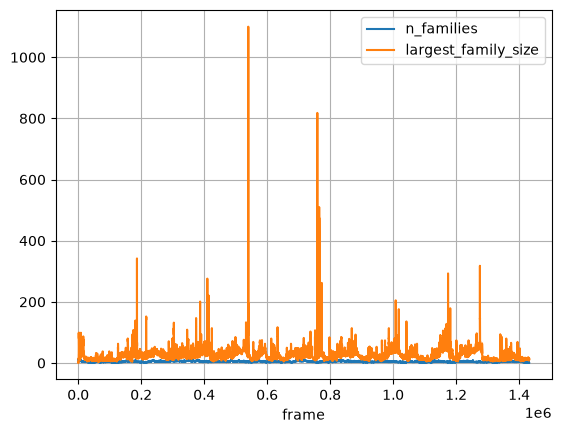

In [ ]:
def f(x):
    return {"n_families": len(x), "largest_family_size": max(x, key=lambda i: i[1])[1]}
df_fam = df["families"].apply(f).apply(pd.Series)
df_fam.plot()

plt.grid(True)

### Population

In [ ]:
df

,simulation_start_ts,unix_ts,n_plants,carnivores,herbivores,omnivores,scavengers,families
frame,,,,,,,,
38,1782850926,1782850927,11,1,1,1,1,"[(0, 1), (1, 1), (2, 1), (3, 1)]"
56,1782850926,1782850927,11,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
211,1782850926,1782850930,12,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
250,1782850926,1782850930,13,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
252,1782850926,1782850930,14,0,1,1,1,"[(0, 1), (2, 1), (3, 1)]"
...,...,...,...,...,...,...,...,...
1431862,1782850926,1782876065,48,0,0,14,0,"[(2, 14)]"
1431864,1782850926,1782876065,49,0,0,14,0,"[(2, 14)]"
1431866,1782850926,1782876065,50,0,0,14,0,"[(2, 14)]"


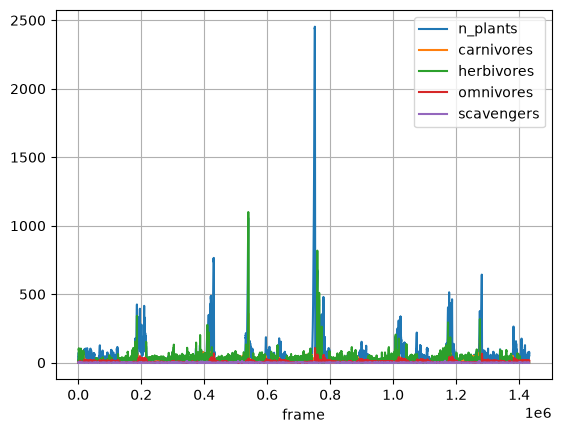

In [ ]:
#df["n_plants"].plot()
df[["n_plants","carnivores", "herbivores", "omnivores", "scavengers"]].plot()
plt.grid()
plt.legend()